In [2]:
'''8. Write a Python program that defines a base class Vehicle with attributes make and model, and a
method display info(). Create a subclass Car that inherits from Vehicle and adds an additional at-
tribute num doors. Instantiate both Vehicle and Car objects, call their display info() methods, and
explain how the subclass inherits and extends the functionality of the base class.'''
class Vehicle:
    def __init__(self,make,model):
        self.make=make
        self.model=model

    def display_info(self):
        print("Make:",self.make)
        print("Model:",self.model)

class Car(Vehicle):
    def __init__(self, make, model,num_doors):
        super().__init__(make, model)
        self.num_doors=num_doors
    
    def display_info(self):
        super().display_info()
        print("Number of Doors:",self.num_doors)

v1 =Vehicle("Toyota","ABC")
c1=Car("Honda","DEF",4)
print("Vehicle info:")
v1.display_info()
print("Car info:")
c1.display_info()


Vehicle info:
Make: Toyota
Model: ABC
Car info:
Make: Honda
Model: DEF
Number of Doors: 4


In [6]:
'''9. Write a Python program demonstrating polymorphism by creating a base class Shape with a method
area(), and two subclasses Circle and Rectangle that override the area() method. Instantiate objects
of both subclasses and call the area() method. Explain how polymorphism simplifies working with
different shapes in an inheritance hierarchy.
'''
import math
class Shape:
    def area(self):
         print("Area")
class Circle(Shape):
     def __init__(self,rad):
          self.rad = rad
          
     def area(self):
          return math.pi*self.rad*self.rad
class Rectangle(Shape):
     def __init__(self,length,breadth):
          self.length=length
          self.breadth=breadth
     
     def area(self):
        return self.length*self.breadth

c1 = Circle(15)
print("Area of circle:",c1.area())

r1 = Rectangle(7,8)
print("Area of circle:",r1.area())


Area of circle: 706.8583470577034
Area of circle: 56


In [3]:
'''10. Implement the CommissionEmployee class with init , earnings, and repr methods. Include
properties for personal details and sales data. Create a test script to instantiate the object, display
earnings, modify sales data, and handle data validation errors for negative values.'''

class CommissionEmployee:
    def __init__(self, first_name, last_name, ssn, gross_sales, commission_rate):
        self.first_name = first_name
        self.last_name = last_name
        self.ssn = ssn
        self.gross_sales = gross_sales
        self.commission_rate = commission_rate

    @property
    def gross_sales(self):
        return self._gross_sales

    @gross_sales.setter
    def gross_sales(self, value):
        if value < 0:
            raise ValueError("Gross sales cannot be negative.")
        self._gross_sales = value

    @property
    def commission_rate(self):
        return self._commission_rate

    @commission_rate.setter
    def commission_rate(self, value):
        if value < 0 or value > 1:
            raise ValueError("Commission rate must be between 0 and 1.")
        self._commission_rate = value

    def earnings(self):
        return self.gross_sales * self.commission_rate

    def __repr__(self):
        return (f"CommissionEmployee({self.first_name} {self.last_name}, "
                f"SSN: {self.ssn}, Gross Sales: {self.gross_sales}, "
                f"Commission Rate: {self.commission_rate})")


def main():
    try:
        emp = CommissionEmployee("Akash", "Gupta", "123-45-6789", 50000, 0.1)
        print(emp)
        print("Earnings:", emp.earnings())
        print("\nUpdating gross sales to 70000...")
        emp.gross_sales = 70000
        print("Updated Earnings:", emp.earnings())
        print("\nTrying to set negative sales...")
        emp.gross_sales = -1000

    except ValueError as e:
        print("Error:", e)


if __name__ == "__main__":
    main()

CommissionEmployee(Akash Gupta, SSN: 123-45-6789, Gross Sales: 50000, Commission Rate: 0.1)
Earnings: 5000.0

Updating gross sales to 70000...
Updated Earnings: 7000.0

Trying to set negative sales...
Error: Gross sales cannot be negative.


In [3]:
'''Q11. What is duck typing in Python? Write a Python program demonstrating duck typing by creating a
function describe() that accepts any object with a speak() method. Implement two classes, Dog and
Robot, each with a speak() method. Pass instances of both classes to the describe() function and
explain how duck typing allows the function to work without checking the object’s type.'''

def describe(obj):
    obj.speak()

class Dog:
    def speak(self):
        print("Dog barks")

class Robot:
    def speak(self):
        print("Robot says Hi!")

d1 = Dog()
r1 = Robot()
describe(d1)
describe(r1)

Dog barks
Robot says Hi!


In [5]:
'''Q12. WAP to overload the + operator to perform addition of two complex numbers using a custom Complex
class?'''

class Complex:
    def __init__(self, real, imag):
        self.real = real
        self.imag = imag
    def __add__(self, other):
        return Complex(self.real + other.real,
                       self.imag + other.imag)

    def __repr__(self):
        return f"{self.real} + {self.imag}i"

c1 = Complex(2,3)
c2 = Complex(4,5)
result = c1+c2
print("Result:", result)

Result: 6 + 8i


In [6]:
'''13. WAP to create a custom exception class in Python that displays the balance and withdrawal amount
when an error occurs due to insufficient funds?'''
class InsufficientFundsError(Exception):
    def __init__(self, balance, withdraw_amount):
        self.balance = balance
        self.withdraw_amount = withdraw_amount
        super().__init__(f"Insufficient funds! Balance: {balance}, Withdrawal: {withdraw_amount}")
class BankAccount:
    def __init__(self, balance):
        self.balance = balance

    def withdraw(self, amount):
        if amount > self.balance:
            raise InsufficientFundsError(self.balance, amount)
        self.balance -= amount
        print("Withdrawal successful! Remaining balance:", self.balance)
try:
    acc = BankAccount(5000)
    acc.withdraw(7000)
except InsufficientFundsError as e:
    print("Error:", e)

Error: Insufficient funds! Balance: 5000, Withdrawal: 7000


In [7]:
'''14. Write a Python program using the Card data class to simulate dealing 5 cards to a player from a
shuffled deck of standard playing cards. The program should print the player’s hand and the number
of remaining cards in the deck after the deal.'''

import random
from dataclasses import dataclass

@dataclass
class Card:
    suit: str
    rank: str

suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10",
         "J", "Q", "K", "A"]

deck = [Card(suit, rank) for suit in suits for rank in ranks]
random.shuffle(deck)

hand = deck[:5]
remaining_deck = deck[5:]

print("Player's Hand:")
for card in hand:
    print(f"{card.rank} of {card.suit}")

print("\nRemaining cards:", len(remaining_deck))

Player's Hand:
10 of Clubs
5 of Hearts
3 of Diamonds
2 of Spades
7 of Clubs

Remaining cards: 47


In [1]:
# 16. Write a Python program that demonstrates unit testing directly within a function’s docstring using the 
# doctest module. Create a function add(a, b) that returns the sum of two numbers and includes 
# multipletest cases in its docstring. Implement a way to automatically run the tests when the script is executed.
def add(a, b):
    """
    Returns the sum of two numbers.
    >>> add(2, 3)
    5
    >>> add(-1, 1)
    0
    >>> add(0, 0)
    0
    """
    return a + b

if __name__ == "__main__":
    import doctest
    doctest.testmod(verbose=True) #doctest.testmod() <-- for (.py) files 

Trying:
    add(2, 3)
Expecting:
    5
ok
Trying:
    add(-1, 1)
Expecting:
    0
ok
Trying:
    add(0, 0)
Expecting:
    0
ok
1 item had no tests:
    __main__
1 item passed all tests:
   3 tests in __main__.add
3 tests in 2 items.
3 passed.
Test passed.


   Celsius  Kelvin
0        0  273.15
1       10  283.15
2       20  293.15
3       30  303.15
4       40  313.15


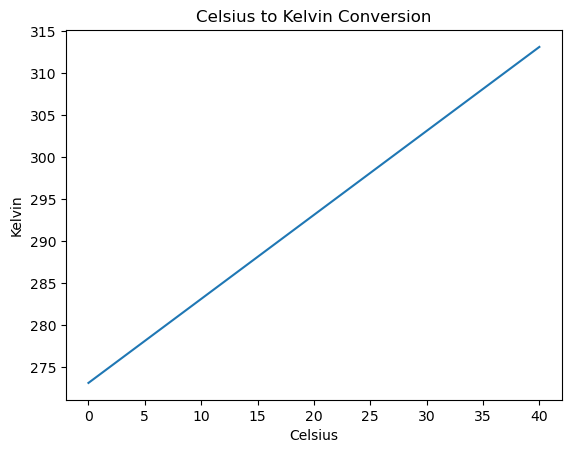

In [2]:
'''
Q18)Write a Python program using a lambda function to convert temperatures from Celsius to Kelvin,
store the data in a tabular format using pandas, and visualize the data using a plot.
'''
import pandas as pd
import matplotlib.pyplot as plt

c_to_k = lambda c: c + 273.15

celsius = [0, 10, 20, 30, 40]
kelvin = list(map(c_to_k, celsius))

df = pd.DataFrame({
    "Celsius": celsius,
    "Kelvin": kelvin
})

print(df)

plt.plot(df["Celsius"], df["Kelvin"])
plt.xlabel("Celsius")
plt.ylabel("Kelvin")
plt.title("Celsius to Kelvin Conversion")
plt.show()